<a href="https://colab.research.google.com/github/oszavla/Dirac-Schwarz/blob/main/Komparasi_Instabilitas_pada_Integrasi_Langsung_dan_Stabilitas_Metode_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metode integrasi langsung dari horizon ke tak hingga

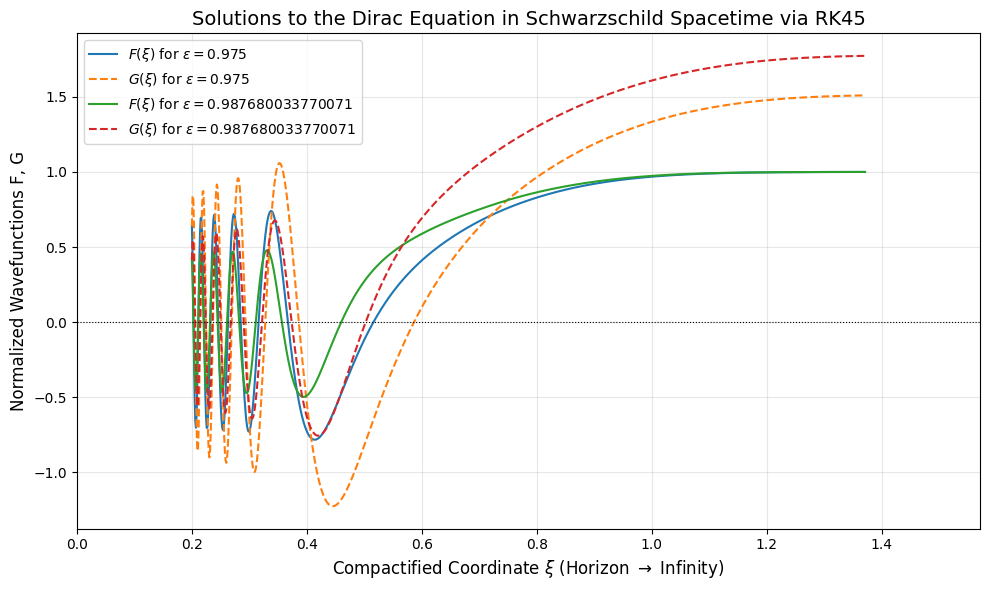

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def dirac_system(xi, y, kappa, alpha_prime, epsilon):
    """
    Defines the coupled differential equations for F and G.
    y[0] = F
    y[1] = G
    """
    F, G = y

    # Precompute trigonometric functions to optimize calculation
    cot_xi = 1.0 / np.tan(xi)
    cos_xi = np.cos(xi)

    # The coupled ODEs
    dF_dxi = (cot_xi**2) * (cos_xi**3) * 2 * kappa * F + \
             4 * alpha_prime * (cot_xi**2) * (cos_xi - epsilon * cot_xi) * G

    dG_dxi = - (cot_xi**2) * (cos_xi**3) * 2 * kappa * G + \
             4 * alpha_prime * (cot_xi**2) * (cos_xi + epsilon * cot_xi) * F

    return [dF_dxi, dG_dxi]

# --- Parameters ---
kappa = 4
alpha_prime = 1.0
epsilons = [0.9750, 0.987680033770071]

# --- Integration Bounds ---
# We offset from 0 and pi/2 by a small delta to avoid coordinate singularities
delta = 0.2
xi_start = delta
xi_end = (np.pi / 2) - delta

# Evaluate at these specific points for smooth plotting
xi_eval = np.linspace(xi_start, xi_end, 1000)

# --- Initial Conditions ---
# A linear homogeneous system initialized exactly at [0,0] remains [0,0].
# We provide a tiny seed value. In rigorous literature, one replaces this
# with the Frobenius asymptotic expansion at xi = delta.
y0 = [1e-8, 1e-8]

# --- Plotting Setup ---
plt.figure(figsize=(10, 6))

# --- Solve for each Eigenvalue ---
for eps in epsilons:
    # Use scipy's solve_ivp with the Adaptive RK45 method
    solution = solve_ivp(
        fun=lambda xi, y: dirac_system(xi, y, kappa, alpha_prime, eps),
        t_span=(xi_start, xi_end),
        y0=y0,
        t_eval=xi_eval,
        method='RK45',
        rtol=1e-8,
        atol=1e-10
    )

    # Extract solutions
    xi_sol = solution.t
    F_sol = solution.y[0]
    G_sol = solution.y[1]

    # Optional: Normalize the wavefunctions so they can be easily compared visually
    max_val = np.max(np.abs(F_sol))
    F_sol = F_sol / max_val
    G_sol = G_sol / max_val

    # Plot
    plt.plot(xi_sol, F_sol, label=rf'$F(\xi)$ for $\epsilon = {eps}$')
    plt.plot(xi_sol, G_sol, linestyle='--', label=rf'$G(\xi)$ for $\epsilon = {eps}$')

# --- Formatting the Graph ---
plt.title('Solutions to the Dirac Equation in Schwarzschild Spacetime via RK45', fontsize=14)
plt.xlabel(r'Compactified Coordinate $\xi$ (Horizon $\to$ Infinity)', fontsize=12)
plt.ylabel('Normalized Wavefunctions F, G', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.xlim(0, np.pi/2)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

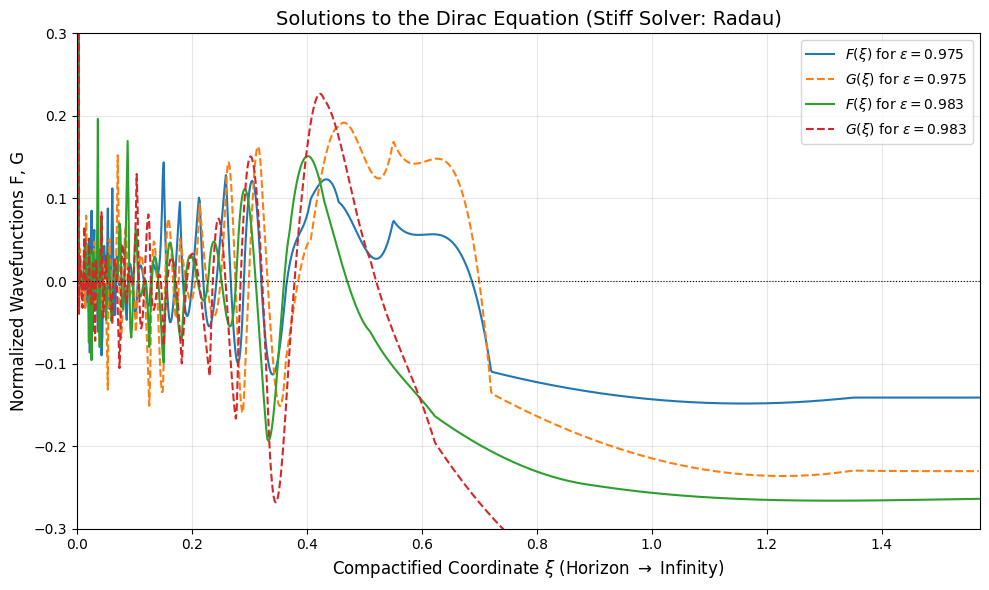

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def dirac_system(xi, y, kappa, alpha_prime, epsilon):
    F, G = y

    # Precompute trigonometric functions
    cot_xi = 1.0 / np.tan(xi)
    cos_xi = np.cos(xi)

    # The coupled ODEs
    # Note: cot(xi) gets dangerously large near xi = 0
    dF_dxi = (cot_xi**2) * (cos_xi**3) * 2 * kappa * F + \
             4 * alpha_prime * (cot_xi**2) * (cos_xi - epsilon * cot_xi) * G

    dG_dxi = - (cot_xi**2) * (cos_xi**3) * 2 * kappa * G + \
             4 * alpha_prime * (cot_xi**2) * (cos_xi + epsilon * cot_xi) * F

    return [dF_dxi, dG_dxi]

# --- Parameters ---
kappa = 4
alpha_prime = 1.0
epsilons = [0.9750, 0.9830]

# --- Integration Bounds ---
# We offset from 0 and pi/2 by a small delta to avoid coordinate singularities
delta = 0.002
xi_start = delta
xi_end = (np.pi / 2) - delta

xi_eval = np.linspace(xi_start, xi_end, 1000)

y0 = [1e-8, 1e-8]

plt.figure(figsize=(10, 6))

for eps in epsilons:

    solution = solve_ivp(
        fun=lambda xi, y: dirac_system(xi, y, kappa, alpha_prime, eps),
        t_span=(xi_start, xi_end),
        y0=y0,
        t_eval=xi_eval,
        method='Radau',
        rtol=1e-5,       # Relaxed from 1e-8
        atol=1e-8        # Relaxed from 1e-10
    )

    # Check if the solver succeeded
    if not solution.success:
        print(f"Solver failed for epsilon={eps}: {solution.message}")
        continue

    xi_sol = solution.t
    F_sol = solution.y[0]
    G_sol = solution.y[1]

    # Calculate dxi for numerical integration (assuming uniform spacing)
    dxi = xi_sol[1] - xi_sol[0]
    cos3_xi = np.cos(xi_sol)**3
    sin_xi = np.sin(xi_sol)

    # Calculate the integral of (|F|^2 + |G|^2) d(xi)
    # This represents the total probability density over the domain
    norm_integral_sq = np.sum((F_sol**2 + G_sol**2) * dxi)
    norm_factor = np.sqrt(norm_integral_sq)
    F_sol = F_sol / norm_factor
    G_sol = G_sol / norm_factor
    # Normalize the wavefunctions so that the integral of their squared magnitude is 1

    # Plot
    plt.plot(xi_sol, F_sol, label=rf'$F(ξ)$ for $ε = {eps}$')
    plt.plot(xi_sol, G_sol, linestyle='--', label=rf'$G(ξ)$ for $ε = {eps}$')

plt.title('Solutions to the Dirac Equation (Stiff Solver: Radau)', fontsize=14)
plt.xlabel(r'Compactified Coordinate $ξ$ (Horizon $\to$ Infinity)', fontsize=12)
plt.ylabel('Normalized Wavefunctions F, G', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.xlim(0, np.pi/2)
plt.ylim(-0.30, 0.30)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

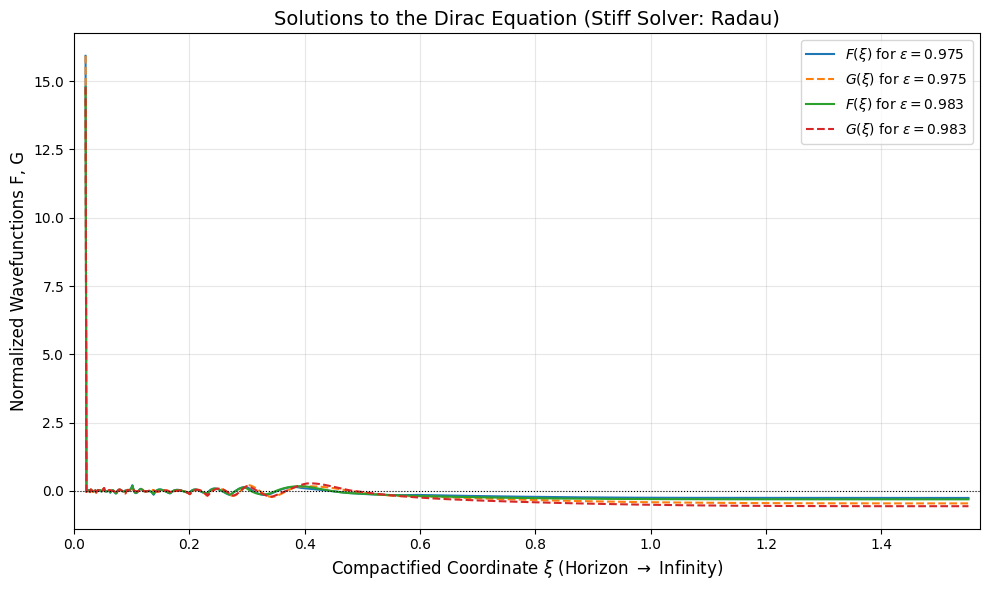

Sweeping epsilon values to find zero-crossings (roots)...


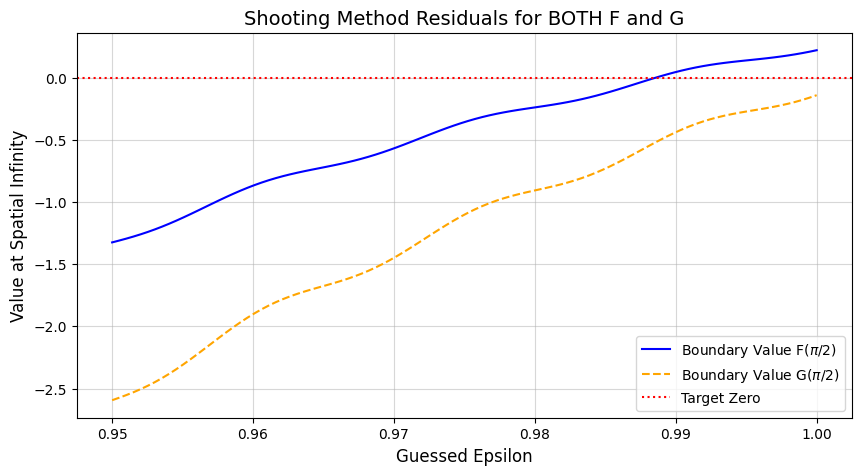

--- Finding exact root ---
Root found! Exact Eigenvalue: 0.988595


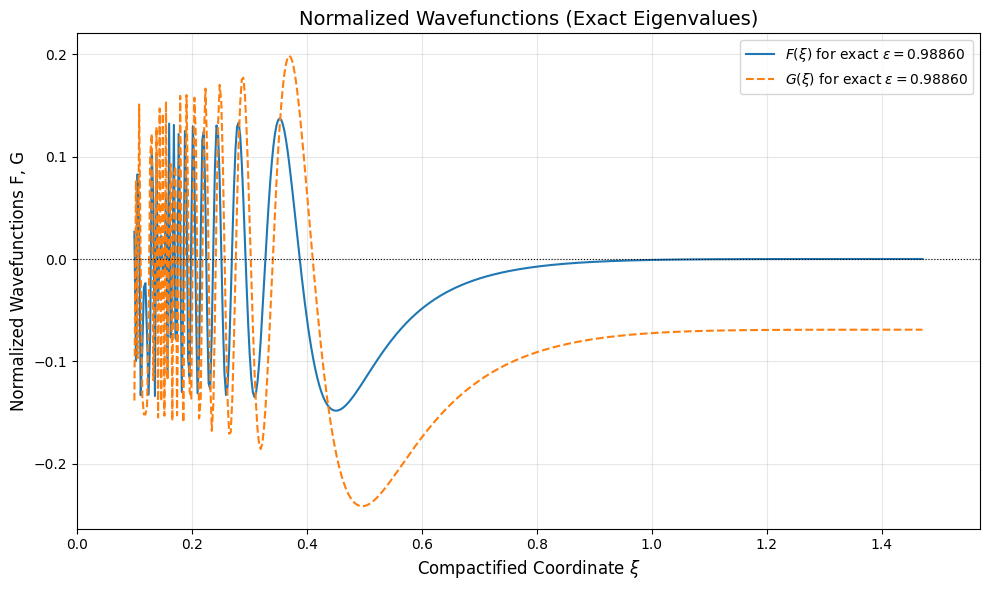

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.integrate import trapezoid

def dirac_system(xi, y, kappa, alpha_prime, epsilon):
    F, G = y
    cot_xi = 1.0 / np.tan(xi)
    cos_xi = np.cos(xi)

    dF_dxi = (cot_xi**2) * (cos_xi**3) * 2 * kappa * F + \
             4 * alpha_prime * (cot_xi**2) * (cos_xi - epsilon * cot_xi) * G

    dG_dxi = - (cot_xi**2) * (cos_xi**3) * 2 * kappa * G + \
             4 * alpha_prime * (cot_xi**2) * (cos_xi + epsilon * cot_xi) * F

    return [dF_dxi, dG_dxi]

# --- Parameters ---
kappa = 4
alpha_prime = 1.0

# --- Integration Bounds ---
delta = 0.1
xi_start = delta
xi_end = (np.pi / 2) - delta
xi_eval = np.linspace(xi_start, xi_end, 500)

def evaluate_boundary_at_infinity(epsilon_guess):
    # Calculate exact initial condition based on asymptotic expansion
    phase = (2 * alpha_prime * epsilon_guess) / (delta**2)

    F0 = np.sin(phase)
    G0 = (1 + delta / epsilon_guess) * np.cos(phase) + \
         (kappa * delta / (2 * alpha_prime * epsilon_guess)) * np.sin(phase)

    y0_exact = [F0, G0]

    solution = solve_ivp(
        fun=lambda xi, y: dirac_system(xi, y, kappa, alpha_prime, epsilon_guess),
        t_span=(xi_start, xi_end),
        y0=y0_exact,
        method='Radau',
        rtol=1e-6,
        atol=1e-8
    )

    # Return a tuple: (F_final, G_final)
    return solution.y[0][-1], solution.y[1][-1]

# ==========================================================
# Phase 1: Sweep to Visualize and Bracket the Roots
# ==========================================================
print("Sweeping epsilon values to find zero-crossings (roots)...")
epsilon_sweep = np.linspace(0.95, 1.0, 100)
F_finals = []
G_finals = []

for eps in epsilon_sweep:
    f_val, g_val = evaluate_boundary_at_infinity(eps)
    F_finals.append(f_val)
    G_finals.append(g_val)

F_finals = np.array(F_finals)
G_finals = np.array(G_finals)

# Plot both sweeps
plt.figure(figsize=(10, 5))
plt.plot(epsilon_sweep, F_finals, label=r"Boundary Value F($\pi/2$)", color='blue')
plt.plot(epsilon_sweep, G_finals, label=r"Boundary Value G($\pi/2$)", color='orange', linestyle='--')
plt.axhline(0, color='red', linestyle=':', label="Target Zero")
plt.title("Shooting Method Residuals for BOTH F and G", fontsize=14)
plt.xlabel("Guessed Epsilon", fontsize=12)
plt.ylabel("Value at Spatial Infinity", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# ==========================================================
# Phase 2: Automated Bracket Detection & Root Finding
# ==========================================================
print("--- Finding exact root ---")
exact_epsilons = []

for i in range(len(epsilon_sweep) - 1):
    if F_finals[i] * F_finals[i+1] < 0:
        bracket_low = epsilon_sweep[i]
        bracket_high = epsilon_sweep[i+1]

        try:
            # Isolate F[0] for the root finder
            root_result = root_scalar(
                lambda e: evaluate_boundary_at_infinity(e)[0],
                bracket=[bracket_low, bracket_high],
                method='brentq'
            )
            exact_eps = root_result.root
            exact_epsilons.append(exact_eps)
            print(f"Root found! Exact Eigenvalue: {exact_eps:.6f}")
        except ValueError:
            pass

# ==========================================================
# Phase 3: Calculate and Plot the Final Normalized Wavefunctions
# ==========================================================
plt.figure(figsize=(10, 6))

# THIS LOOP MUST CONTAIN THE PLOTTING AND NORMALIZATION
for eps in exact_epsilons:
    # Calculate exact initial condition for plotting
    phase = (2 * alpha_prime * eps) / (delta**2)
    F0 = np.sin(phase)
    G0 = (1 + delta / eps) * np.cos(phase) + \
         (kappa * delta / (2 * alpha_prime * eps)) * np.sin(phase)

    y0_exact = [F0, G0]

    solution = solve_ivp(
        fun=lambda xi, y: dirac_system(xi, y, kappa, alpha_prime, eps),
        t_span=(xi_start, xi_end),
        y0=y0_exact,
        t_eval=xi_eval,
        method='Radau',
        rtol=1e-6,
        atol=1e-8
    )

    xi_sol = solution.t
    F_sol = solution.y[0]
    G_sol = solution.y[1]

    # 1. Calculate the Jacobian measure ( d_rho / d_xi )
    measure = 4 * alpha_prime * np.sin(xi_sol) / (np.cos(xi_sol)**3 + 1e-12)

    # 2. Define the integrand: (|F|^2 + |G|^2) * measure
    integrand = (F_sol**2 + G_sol**2) * measure

    # 3. Integrate over the domain xi using the Trapezoidal rule
    probability_integral = trapezoid(integrand, xi_sol)

    # 4. Calculate the true physical normalization constant N
    if probability_integral > 0:
        N = 1.0 / np.sqrt(probability_integral)
    else:
        N = 1.0

    # 5. Apply the rigorous normalization
    F_sol = F_sol * N
    G_sol = G_sol * N

    # 6. Plot the lines inside the loop so we see all eigen-states!
    plt.plot(xi_sol, F_sol, label=rf'$F(\xi)$ for exact $\epsilon = {eps:.5f}$')
    plt.plot(xi_sol, G_sol, linestyle='--', label=rf'$G(\xi)$ for exact $\epsilon = {eps:.5f}$')

plt.title('Normalized Wavefunctions (Exact Eigenvalues)', fontsize=14)
plt.xlabel(r'Compactified Coordinate $\xi$', fontsize=12)
plt.ylabel('Normalized Wavefunctions F, G', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.xlim(0, np.pi/2)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Metode Matching Cohen-Soffel

Searching for bound state eigenvalue...
Convergence Successful! Energy Eigenvalue epsilon = 0.950289


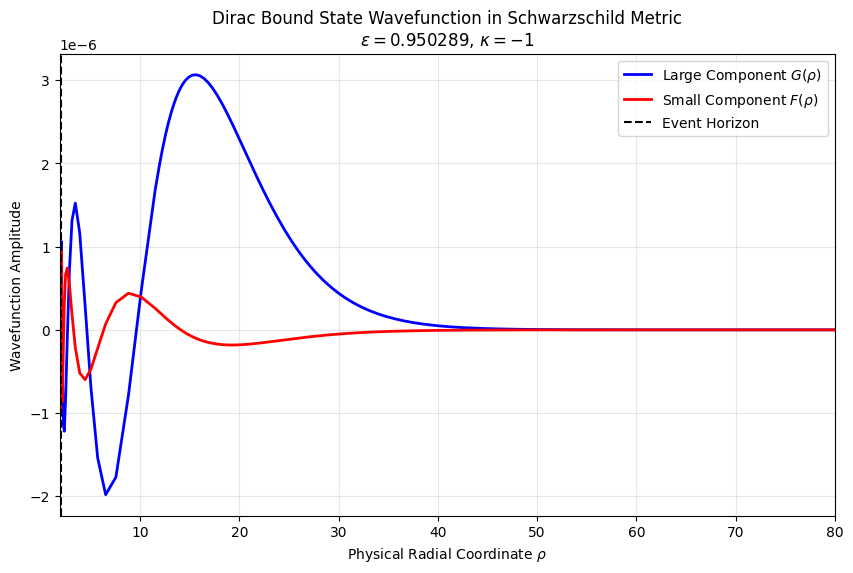

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.special import lambertw

# --- Physical Parameters ---
alpha_prime = 1.0   # M / lambda_c
kappa = -1          # Ground state spin-orbit number

# --- Coordinate Mapping ---
def get_rho(rho_star):
    """
    Exactly converts Tortoise coordinate (rho*) to physical radial coordinate (rho)
    using the analytical Lambert W function.
    """
    # z = exp((rho* - 2a) / 2a)
    z = np.exp((rho_star - 2 * alpha_prime) / (2 * alpha_prime))
    # rho = 2a * [1 + W(z)]
    # We take the real part since we are in the strictly positive domain
    w = lambertw(z)
    return 2 * alpha_prime * (1 + np.real(w))

# --- The Smooth ODE System ---
def dirac_tortoise_system(rho_star, y, epsilon):
    """
    y[0] = G, y[1] = F
    Derivatives are with respect to rho*
    """
    G, F = y
    rho = get_rho(rho_star)
    f = 1 - 2 * alpha_prime / rho
    sqrt_f = np.sqrt(f)

    # The equations multiplied by f (d/drho* = f * d/drho)
    dG = -sqrt_f * (kappa / rho) * G + (sqrt_f + epsilon) * F
    dF =  sqrt_f * (kappa / rho) * F + (sqrt_f - epsilon) * G

    return [dG, dF]

# --- The Shooting Method Engine ---
def compute_mismatch(epsilon, return_wavefunction=False):
    # Integration Boundaries (Tortoise Coordinates)
    rho_star_min = -50.0  # Deep near the event horizon
    rho_star_max = 200.0  # Spatial infinity
    rho_star_match = 15.0 # Intermediate matching point

    # 1. Asymptotic Initial Conditions at Horizon (rho* -> -infty)
    # G ~ sin(eps * rho*), F ~ cos(eps * rho*)
    G_out_init = 1e-6 * np.sin(epsilon * rho_star_min)
    F_out_init = 1e-6 * np.cos(epsilon * rho_star_min)

    # 2. Asymptotic Initial Conditions at Infinity (rho* -> +infty)
    # G ~ e^(-lambda * rho*), F = -sqrt((1-eps)/(1+eps)) * G
    G_in_init = 1e-6
    F_in_init = -np.sqrt((1 - epsilon) / (1 + epsilon)) * G_in_init

    # Outward Integration
    sol_out = solve_ivp(
        dirac_tortoise_system,
        t_span=[rho_star_min, rho_star_match],
        y0=[G_out_init, F_out_init],
        args=(epsilon,),
        method='RK45', dense_output=True, rtol=1e-8, atol=1e-10
    )

    # Inward Integration
    sol_in = solve_ivp(
        dirac_tortoise_system,
        t_span=[rho_star_max, rho_star_match],
        y0=[G_in_init, F_in_init],
        args=(epsilon,),
        method='RK45', dense_output=True, rtol=1e-8, atol=1e-10
    )

    # Extract matching point values
    G_out, F_out = sol_out.y[:, -1]
    G_in, F_in   = sol_in.y[:, -1]

    # Enforce continuity by scaling the inward solution
    scale_factor = F_out / F_in
    G_in_scaled = G_in * scale_factor

    # Mismatch is the discontinuity in G
    mismatch = G_out - G_in_scaled

    if return_wavefunction:
        return sol_out, sol_in, scale_factor
    return mismatch

# --- Execution & Plotting ---
print("Searching for bound state eigenvalue...")

# Bracket roughly where we expect the ground state (e.g., 0.95 to 0.999)
result = root_scalar(compute_mismatch, bracket=[0.95, 0.999], method='brentq')

if result.converged:
    eigenvalue = result.root
    print(f"Convergence Successful! Energy Eigenvalue epsilon = {eigenvalue:.6f}")

    # Re-run the integration at the exact eigenvalue to extract the wavefunctions
    sol_out, sol_in, scale_factor = compute_mismatch(eigenvalue, return_wavefunction=True)

    # Splice the solutions together
    rho_star_vals = np.concatenate((sol_out.t, sol_in.t[::-1]))
    G_vals = np.concatenate((sol_out.y[0], sol_in.y[0][::-1] * scale_factor))
    F_vals = np.concatenate((sol_out.y[1], sol_in.y[1][::-1] * scale_factor))

    # Map tortoise coordinate back to physical coordinate for intuitive plotting
    rho_vals = np.array([get_rho(rs) for rs in rho_star_vals])

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(rho_vals, G_vals, label=r'Large Component $G(\rho)$', color='blue', lw=2)
    plt.plot(rho_vals, F_vals, label=r'Small Component $F(\rho)$', color='red', lw=2)

    plt.axvline(2*alpha_prime, color='black', linestyle='--', label="Event Horizon")
    plt.title(f"Dirac Bound State Wavefunction in Schwarzschild Metric\n$\\epsilon = {eigenvalue:.6f}$, $\\kappa = {kappa}$")
    plt.xlabel(r"Physical Radial Coordinate $\rho$")
    plt.ylabel("Wavefunction Amplitude")
    plt.xlim(1.9, 80) # Zoomed in to see the well
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Failed to converge on an eigenvalue.")